# 04 Baseline Models (LFD Foundations)

This notebook implements the baseline model family for post-game, team-level match prediction.

LFD anchors:
- PLA feasibility of learning: Perceptron as a linear separator baseline.
- Linear models and optimization differences: pseudo-inverse (linear regression) vs iterative optimization (logistic regression).
- Generalization: explicit train/val/test split with $E_{in}$ (train) and $E_{out}$ proxies (val/test).

In [1]:
from __future__ import annotations

import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from oracle.models import ModelConfig, Trainer, TrainingConfig
from oracle.models.baseline import BASELINE_MODEL_NAMES, build_baseline_model
from oracle.utils import load_yaml_config
from oracle.utils.constants import CONFIGS_DIR, REPORTS_DIR

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

BASELINE_MODEL_NAMES

/home/amir/dev/lol-match-oracle/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


('logistic_regression', 'perceptron', 'linear_regression_classifier')

In [2]:
training_mapping = load_yaml_config(CONFIGS_DIR / "training.yaml")
model_mapping = load_yaml_config(CONFIGS_DIR / "model.yaml")

training_template = TrainingConfig.from_mapping(
    training_mapping,
    base_dir=CONFIGS_DIR.parent,
    experiment_name_override="01-baselines",
)

train_frame = pd.read_csv(training_template.processed_dir / "train_features.csv.gz")
val_frame = pd.read_csv(training_template.processed_dir / "val_features.csv.gz")
test_frame = pd.read_csv(training_template.processed_dir / "test_features.csv.gz")

print("train:", train_frame.shape, "val:", val_frame.shape, "test:", test_frame.shape)

train: (250972, 45) val: (35854, 45) test: (71708, 45)


## Baseline Training With MLflow

Validation discipline:
- Fit only on train split.
- Use validation split for development diagnostics.
- Use test split for final baseline comparison only.

Regularization and complexity control:
- Logistic regression uses configurable L2 settings from config.
- Perceptron and linear regression classifier keep linear hypothesis class as low-complexity references.

In [3]:
def _run_baseline(model_name: str) -> dict[str, object]:
    model_config = ModelConfig.from_mapping(model_mapping, model_name_override=model_name)
    training_config = TrainingConfig.from_mapping(
        training_mapping,
        base_dir=CONFIGS_DIR.parent,
        experiment_name_override="01-baselines",
        run_name_override=f"{model_name}-baseline",
    )

    trainer = Trainer(training_config=training_config, model_config=model_config)
    result = trainer.train(train_frame, val_frame, test_frame)

    return {
        "model_name": model_name,
        "run_id": result.run_id,
        "model_path": str(result.model_path),
        "accuracy": result.metrics["test_accuracy"],
        "precision": result.metrics["test_precision"],
        "recall": result.metrics["test_recall"],
        "f1": result.metrics["test_f1"],
        "roc_auc": result.metrics.get("test_roc_auc", float("nan")),
        "training_time": result.metrics["fit_seconds"],
        "ein_train_error": 1.0 - result.metrics["train_accuracy"],
        "eout_val_error": 1.0 - result.metrics["val_accuracy"],
        "eout_test_error": 1.0 - result.metrics["test_accuracy"],
    }

baseline_rows: list[dict[str, object]] = []
for model_name in ["perceptron", "linear_regression_classifier", "logistic_regression"]:
    baseline_rows.append(_run_baseline(model_name))

baseline_metrics = pd.DataFrame(baseline_rows).sort_values("roc_auc", ascending=False)

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
metrics_csv = REPORTS_DIR / "baseline_comparison_metrics.csv"
metrics_json = REPORTS_DIR / "baseline_comparison_metrics.json"
baseline_metrics.to_csv(metrics_csv, index=False)
metrics_json.write_text(
    json.dumps(baseline_rows, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)

print(f"Saved artifacts: {metrics_csv} and {metrics_json}")
baseline_metrics

2026/04/19 21:24:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/19 21:24:34 INFO mlflow.store.db.utils: Updating database tables
2026/04/19 21:24:37 INFO mlflow.tracking.fluent: Experiment with name '01-baselines' does not exist. Creating a new experiment.
2026-04-19 21:24:37,615 | INFO | Starting training run 'perceptron-baseline' in experiment '01-baselines'
2026-04-19 21:24:38,491 | INFO | Completed training run 'perceptron-baseline' (run_id=80247db0acec48a7a5f0a7cbc15800e8)
2026-04-19 21:24:38,562 | INFO | Starting training run 'linear_regression_classifier-baseline' in experiment '01-baselines'
2026-04-19 21:24:40,135 | INFO | Completed training run 'linear_regression_classifier-baseline' (run_id=1fce0a40b7e349a8bda26ade33bfe7b2)
2026-04-19 21:24:40,207 | INFO | Starting training run 'logistic_regression-baseline' in experiment '01-baselines'
2026-04-19 21:24:42,114 | INFO | Completed training run 'logistic_regression-baseline' (run_id=1ddd938cfc

Saved artifacts: /home/amir/dev/lol-match-oracle/reports/baseline_comparison_metrics.csv and /home/amir/dev/lol-match-oracle/reports/baseline_comparison_metrics.json


,model_name,run_id,model_path,accuracy,precision,recall,f1,roc_auc,training_time,ein_train_error,eout_val_error,eout_test_error
2,logistic_regression,1ddd938cfc6e434e864d0d36ca2db9f2,/home/amir/dev/lol-match-oracle/models/01-base...,0.984827,0.984827,0.984827,0.984827,0.998527,1.309698,0.015452,0.014894,0.015173
1,linear_regression_classifier,1fce0a40b7e349a8bda26ade33bfe7b2,/home/amir/dev/lol-match-oracle/models/01-base...,0.675796,0.606668,0.999833,0.755140,0.997348,0.994984,0.323956,0.321694,0.324204
0,perceptron,80247db0acec48a7a5f0a7cbc15800e8,/home/amir/dev/lol-match-oracle/models/01-base...,0.977659,0.980204,0.975010,0.977600,0.994484,0.289738,0.022437,0.021225,0.022341


## Error Analysis

Error diagnostics compare false positives and false negatives on the held-out test split.

Interpretation reminder:
- Lower $E_{out}$ indicates better generalization under current split assumptions.
- Differences across linear baselines suggest optimization effects rather than large hypothesis-class changes.

In [4]:
def _extract_xy(frame: pd.DataFrame, training_config: TrainingConfig) -> tuple[pd.DataFrame, pd.Series]:
    required = [*training_config.id_columns, training_config.target_column]
    feature_cols = [column for column in frame.columns if column not in set(required)]
    x = frame[feature_cols].copy()
    y = frame[training_config.target_column].astype(int)
    return x, y

x_test, y_test = _extract_xy(test_frame, training_template)

error_rows: list[dict[str, object]] = []
for row in baseline_rows:
    model_path = Path(str(row["model_path"]))
    with model_path.open("rb") as handle:
        model = pickle.load(handle)

    y_pred = model.predict(x_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    error_rows.append(
        {
            "model_name": row["model_name"],
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "total_errors": int(fp + fn),
            "test_error": float(1.0 - accuracy_score(y_test, y_pred)),
        }
    )

error_analysis = pd.DataFrame(error_rows).sort_values("test_error")
error_analysis

,model_name,false_positives,false_negatives,total_errors,test_error
2,logistic_regression,544,544,1088,0.015173
0,perceptron,706,896,1602,0.022341
1,linear_regression_classifier,23242,6,23248,0.324204


## Learning Curves ($N$ vs $E_{out}$)

The curve uses validation error as the out-of-sample proxy while varying training size.

# NOTE: This avoids reusing the test split during development analysis.

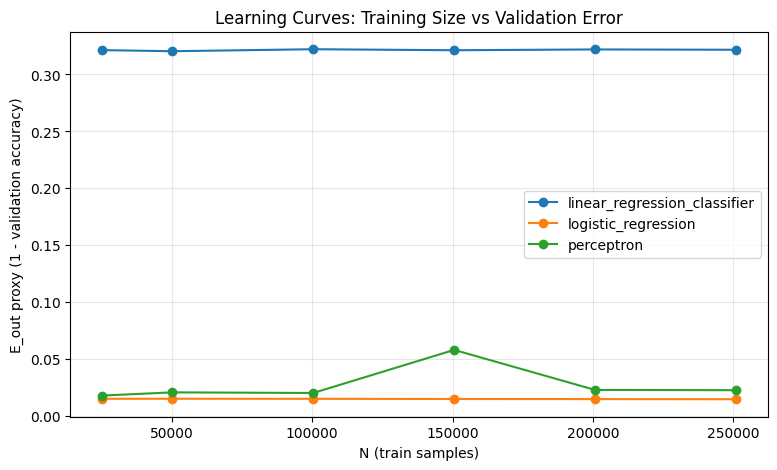

Saved learning curve artifact: /home/amir/dev/lol-match-oracle/reports/baseline_learning_curves.csv


,model_name,n_samples,e_out
0,perceptron,25097,0.018073
1,perceptron,50194,0.020918
2,perceptron,100388,0.020360
3,perceptron,150583,0.058180
4,perceptron,200777,0.023066


In [5]:
x_train, y_train = _extract_xy(train_frame, training_template)
x_val, y_val = _extract_xy(val_frame, training_template)

fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
rng = np.random.default_rng(SEED)
curve_rows: list[dict[str, float | str | int]] = []

for model_name in ["perceptron", "linear_regression_classifier", "logistic_regression"]:
    model_params = ModelConfig.from_mapping(model_mapping, model_name_override=model_name).model_params

    for frac in fractions:
        n_samples = max(64, int(len(x_train) * frac))
        sample_idx = rng.choice(len(x_train), size=n_samples, replace=False)

        x_sub = x_train.iloc[sample_idx]
        y_sub = y_train.iloc[sample_idx]

        model = build_baseline_model(model_name, params=model_params, random_state=SEED)
        if model is None:
            raise RuntimeError(f"Expected baseline model for key: {model_name}")

        model.fit(x_sub, y_sub)
        val_pred = model.predict(x_val)
        e_out = 1.0 - accuracy_score(y_val, val_pred)

        curve_rows.append(
            {
                "model_name": model_name,
                "n_samples": int(n_samples),
                "e_out": float(e_out),
            }
        )

learning_curve_df = pd.DataFrame(curve_rows)
learning_curve_path = REPORTS_DIR / "baseline_learning_curves.csv"
learning_curve_df.to_csv(learning_curve_path, index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for model_name, group in learning_curve_df.groupby("model_name"):
    group = group.sort_values("n_samples")
    ax.plot(group["n_samples"], group["e_out"], marker="o", label=model_name)

ax.set_title("Learning Curves: Training Size vs Validation Error")
ax.set_xlabel("N (train samples)")
ax.set_ylabel("E_out proxy (1 - validation accuracy)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

print(f"Saved learning curve artifact: {learning_curve_path}")
learning_curve_df.head()

## LFD Summary

- PLA feasibility: Perceptron performance indicates how close the engineered features are to linear separability.
- Optimization differences: linear regression uses a closed-form pseudo-inverse, while logistic regression optimizes cross-entropy iteratively.
- Generalization discipline: model selection uses train/val behavior, and final comparison uses test only once per baseline family.